### Text Descriptors

In [27]:
# all necessary imports are listed below
import os
import random
import cv2
import matplotlib.pyplot as plt
import re
import psycopg2
import psycopg2.extras



Image Path: C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Website\paintings\Post_Impressionism\pyotr-konchalovsky_novgorod-the-fish-market-1928.jpg
Genre: Post Impressionism 
Artist: Pyotr Konchalovsky 
Painting Name: Novgorod The Fish Market  
Year: 1928


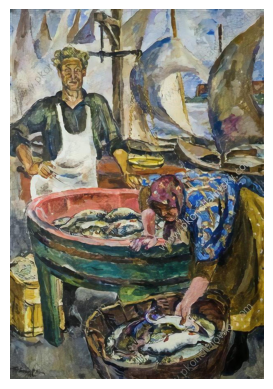

In [3]:
dataset_path = r'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Website\paintings'

# pick a random genre and image 
genre = random.choice(os.listdir(dataset_path))
rand_genre_path = os.path.join(dataset_path, genre)
rand_img = random.choice(os.listdir(rand_genre_path))
img_path = os.path.join(rand_genre_path, rand_img)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# parse filename for genre, artist, painting, and year 
filename = os.path.splitext(rand_img)[0]  
parts = filename.split("_")                

artist_part = parts[0]
painting_part = "_".join(parts[1:])
match = re.search(r"\b\d{4}\b", painting_part)
if match:
    year = match.group(0)
    painting_part = painting_part.replace(year, "").replace("-", " ")
else:
    year = "Unknown"
    painting_part = painting_part.replace("-", " ")

# clean up outputs and display results
genre = genre.replace("_", " ").title()
artist = artist_part.replace("-", " ").title()
painting_name = painting_part.replace("-", " ").title()

print("Image Path:", img_path)
print(f"Genre: {genre} \nArtist: {artist} \nPainting Name: {painting_name} \nYear: {year}")

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [4]:
def text_features(img_path):    
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # parse filename for genre, artist, painting, and year 
    genre = os.path.basename(os.path.dirname(img_path))
    filename = os.path.splitext(os.path.basename(img_path))[0] 
    parts = filename.split("_")                

    artist_part = parts[0]
    painting_part = "_".join(parts[1:])
    match = re.search(r"\b\d{4}\b", painting_part)
    if match:
        year = match.group(0)
        painting_part = painting_part.replace(year, "").replace("-", " ")
    else:
        year = "Unknown"
        painting_part = painting_part.replace("-", " ")

    # clean up outputs and display results
    genre = genre.replace("_", " ").title()
    artist = artist_part.replace("-", " ").title()
    painting_name = painting_part.replace("-", " ").title()

    return image_rgb, genre, artist, genre, painting_name, year

### Database Text Descriptors 

In [2]:
# Extract Artist and Painting Metadata from ART_RECSYS_DB

# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="ART_RECSYS_DB",
        user="postgres",
        password="Catmelon304!"
    )
    return conn


### Preprocessing
#### Validation and Cleaning

In [36]:
# Validation for meta data before cleaning and checking for NULLs/empty cells
def validate_all_paintings():
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Fetch all paintings with artist info
    cur.execute("""
        SELECT
            painting_id,
            title,
            year_created,
            genre,
            art_style,
            media,
            description_tags,
            image_path,
            artist_artist_id,
            name_surname,
            birth_year,
            death_year,
            nationality,
            fields,
            art_movements,
            bio
        FROM paintings_and_artists_metadata
    """)

    rows = cur.fetchall()
    cur.close()
    conn.close()

    validation_results = []

    for row in rows:
        errors = []
        pid = row["painting_id"]

        # Year validation
        year = row["year_created"]
        if year is not None:
            if not (1000 <= year <= 2026):
                errors.append("invalid_year_created")

        # Artist lifespan consistency
        birth = row["birth_year"]
        death = row["death_year"]
        if birth is not None and death is not None:
            if birth > death:
                errors.append("invalid_lifespan")

        # Painting before artist birth
        if year is not None and birth is not None:
            if year < birth:
                errors.append("painting_before_birth")

        if errors:
            validation_results.append({
                "painting_id": pid,
                "title": row["title"],
                "errors": errors
            })

    return validation_results

validation_results = validate_all_paintings()
print(validation_results)

[]


#### Extracting Year from Title, Wrong Year from Title, Wrong Year and Removed

In [22]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
def extract_year_from_title(title):
    if not title:
        return None

    # Match years between 1000–2026
    matches = re.findall(r"\b(1[0-9]{3}|20[0-2][0-6])\b", title)

    if not matches:
        return None

    return int(matches[-1])

def fix_years_from_titles(paintings_with_errors):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    for item in paintings_with_errors:
        pid = item["painting_id"]
        title = item["title"]

        extracted_year = extract_year_from_title(title)

        if extracted_year:
            print(f"Updating painting {pid}: setting year_created to {extracted_year}")

            cur.execute("""
                UPDATE paintings_and_artists_metadata
                SET year_created = %s
                WHERE painting_id = %s
            """, (extracted_year, pid))
        else:
            print(f"Skipping painting {pid}: no valid year found in title")

    conn.commit()
    cur.close()
    conn.close()

fix_years_from_titles(validation_results)

Updating painting 103: setting year_created to 1985
Updating painting 104: setting year_created to 1991
Updating painting 105: setting year_created to 1984
Updating painting 106: setting year_created to 1984
Updating painting 114: setting year_created to 1960
Updating painting 117: setting year_created to 1962
Skipping painting 924: no valid year found in title
Skipping painting 1319: no valid year found in title
Updating painting 2257: setting year_created to 1985
Updating painting 2431: setting year_created to 1972
Updating painting 2434: setting year_created to 1975
Skipping painting 2530: no valid year found in title
Skipping painting 3234: no valid year found in title
Updating painting 3624: setting year_created to 1912
Updating painting 3844: setting year_created to 1908
Skipping painting 3881: no valid year found in title
Updating painting 3894: setting year_created to 1952
Updating painting 4124: setting year_created to 1896
Updating painting 4256: setting year_created to 1908


In [31]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
wrong_year_move_to_title  = [{'painting_id': 3234,
  'title': 'Prince Ukhtomsky In The Battle With Tartars At Volga In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 3881,
  'title': 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 5278,
  'title': 'Design For The  Piastres Porto Brand Of Austrian Post In The Levant Not Issued',
  'errors': ['painting_before_birth']},
 {'painting_id': 15055,
  'title': 'Aleksandra Ekster Costume Designs For A  Production Of Salome',
  'errors': ['painting_before_birth']},
 {'painting_id': 18191,
  'title': 'Founding Act Of The Municipal Savings Bank Of Vitoria In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 18319, 'title': 'P ', 'errors': ['invalid_year_created']},
 {'painting_id': 46503,
  'title': 'Crusaders Arrived In Constantinople Battle Between The French And Turks In  And 1148',
  'errors': ['painting_before_birth']},
 {'painting_id': 46517,
  'title': 'Entry Of Louis Vii C  80 King Of France And Conrad Iii 1093 1152 King Of Germany Into',
  'errors': ['painting_before_birth']},
 {'painting_id': 46563,
  'title': 'The Arrival Of Charles V  80 In Paris 28Th May 1364',
  'errors': ['painting_before_birth']},
 {'painting_id': 39665,
  'title': 'Catherine Of Siena Escorted Pope Gregory Xi At Rome On 17Th January  ',
  'errors': ['painting_before_birth']},
  {'painting_id': 69406,
  'title': 'The Preaching Of John Knox Before The Lords Of Congregation 10 June  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 69872,
  'title': 'First Observation Of The Transit Of Venus By William Crabtree In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 69901,
  'title': 'The Proclamation Regarding Weights And Measures  Illustration From Hutchinson S Story Of',
  'errors': ['painting_before_birth']},
 {'painting_id': 71490,
  'title': 'Chopin Performing In The Guest Hall Of Anton Radziville In Berlin In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 73536,
  'title': 'Proclamation Of Kuzma Minin In Nizhny Novgorod In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 77134,
  'title': 'Parade In The  ',
  'errors': ['painting_before_birth']},
  {'painting_id': 49648,
  'title': 'Unknown  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 60771,
  'title': 'Statesmen No  Caricature Of The Rt Hon Cp Villiers M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 60772,
  'title': 'Statesmen No  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 60773,
  'title': 'Statesmen No  Caricature Of The Rt Hon Hbw Brand M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 60774,
  'title': 'Statesmen No  Caricature Of Mr Roger Eykyn Liberal M P For Windsor',
  'errors': ['painting_before_birth']},
 {'painting_id': 60775,
  'title': 'Statesmen No  Caricature Of Sir Francis Goldsmid M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 66648,
  'title': 'The Battle Of La Hogue Destruction Of The French Fleet May 22  Detail',
  'errors': ['painting_before_birth']},
 {'painting_id': 66649,
  'title': 'The Battle Of La Hogue Destruction Of The French Fleet May 22  ',
  'errors': ['painting_before_birth']}]

def insert_year_into_title(title, year):
    if not title or not year:
        return title

    year_str = str(year)

    # If double space exists then insert year there
    if "  " in title:
        new_title = title.replace("  ", f" {year_str} ", 1)
    
    # If ends with space then append at the end
    elif title.endswith(" "):
        new_title = title + year_str
    
    # fallback
    else:
        new_title = f"{title} {year_str}"

    # Clean extra whitespace
    new_title = re.sub(r"\s+", " ", new_title).strip()

    return new_title

def move_year_to_title(paintings_list):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    for item in paintings_list:
        pid = item["painting_id"]

        # Fetch current title + year
        cur.execute("""
            SELECT title, year_created
            FROM paintings_and_artists_metadata
            WHERE painting_id = %s
        """, (pid,))
        
        row = cur.fetchone()
        if not row:
            print(f"Skipping {pid}: not found")
            continue

        title = row["title"]
        year = row["year_created"]

        if not year:
            print(f"Skipping {pid}: no year to move")
            continue

        new_title = insert_year_into_title(title, year)

        print(f"{pid}: '{title}' → '{new_title}'")

        # Update DB
        cur.execute("""
            UPDATE paintings_and_artists_metadata
            SET title = %s,
                year_created = NULL
            WHERE painting_id = %s
        """, (new_title, pid))

    conn.commit()
    cur.close()
    conn.close()

move_year_to_title(wrong_year_move_to_title)

3234: 'Prince Ukhtomsky In The Battle With Tartars At Volga In ' → 'Prince Ukhtomsky In The Battle With Tartars At Volga In 1469'
3881: 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July ' → 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July 1556'
5278: 'Design For The  Piastres Porto Brand Of Austrian Post In The Levant Not Issued' → 'Design For The 1102 Piastres Porto Brand Of Austrian Post In The Levant Not Issued'
15055: 'Aleksandra Ekster Costume Designs For A  Production Of Salome' → 'Aleksandra Ekster Costume Designs For A 1917 Production Of Salome'
18191: 'Founding Act Of The Municipal Savings Bank Of Vitoria In ' → 'Founding Act Of The Municipal Savings Bank Of Vitoria In 1850'
18319: 'P ' → 'P 5533'
46503: 'Crusaders Arrived In Constantinople Battle Between The French And Turks In  And 1148' → 'Crusaders Arrived In Constantinople Battle Between The French And Turks In 1148 And 1148'
46517: 'Entry Of Louis Vii C  80 King Of Fra

In [35]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
def nullify_invalid_years(validation_results):
    conn = get_db_connection()
    cur = conn.cursor()

    for item in validation_results:
        pid = item["painting_id"]

        cur.execute("""
            UPDATE paintings_and_artists_metadata
            SET year_created = NULL
            WHERE painting_id = %s
        """, (pid,))

        print(f"Set year_created = NULL for painting_id {pid}")

    conn.commit()
    cur.close()
    conn.close()

nullify_invalid_years(validation_results)

Set year_created = NULL for painting_id 924
Set year_created = NULL for painting_id 1319
Set year_created = NULL for painting_id 2530
Set year_created = NULL for painting_id 41546
Set year_created = NULL for painting_id 42825
Set year_created = NULL for painting_id 48910
Set year_created = NULL for painting_id 67146


#### Handling Missing Values for all metadata fields 